# Uczenie głębokie 


## laboratorium: Modele generatywne

Najważniejsze koncepcje :
-  GAN
-  Model dyfuzyjny

## Pomocne materiały

- https://github.com/joseph-nagel/diffusion-demo/blob/main/diffusion/ddpm/base.py
- https://huggingface.co/blog/annotated-diffusion
- https://github.com/hamidkarimi/GAN-SwissRoll/blob/master/Description.pdf

# Importy

In [1]:
import seaborn as sns
import pandas as pd

import jax
import jax.numpy as jnp

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import keras
from IPython.display import display, Markdown
import keras
import tensorflow as tf
from keras import ops

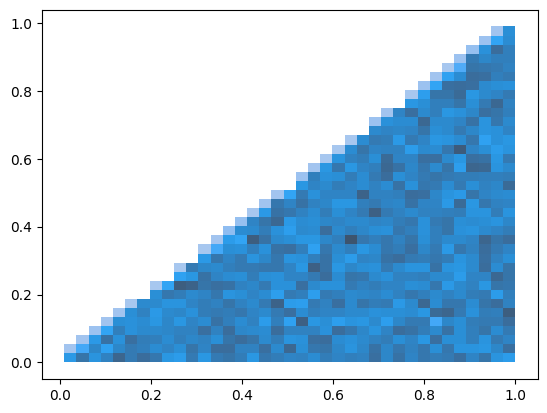

In [2]:
points=[]
for _ in range(20000):
    x = np.random.beta(a=2, b=1)
    y = np.random.uniform(0,x)
    points.append((x,y))

points=np.asarray(points)

sns.histplot(x=points[:,0],y=points[:,1], stat='density');

# Dane

Pracujemy na danych syntetycznych 2d $(x,y)$

- $x\sim\mathcal{N}(x,0,1)$
- $y|x\sim\mathcal{N}(y,\cos(x),\frac{1}{4})$

<Axes: >

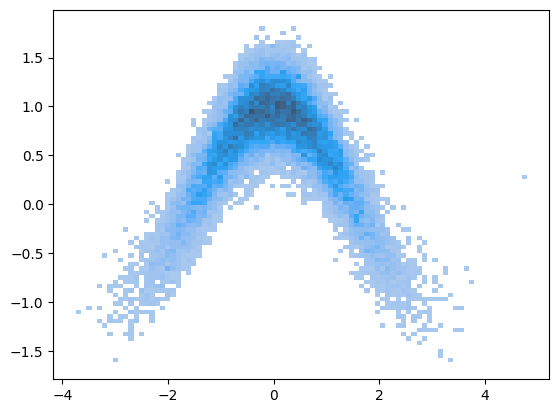

In [3]:
n_sample = 20_000
np.random.seed(55)

def gen_data(n_sample):
    x = np.random.normal(size=n_sample)
    y = np.cos(x) + np.random.normal(scale=0.25, size=n_sample)
    return np.stack([x,y], axis=1)
points = gen_data(n_sample)
sns.histplot(x=points[:,0],y=points[:,1], stat='density')

# GAN

## Zadanie zaimplementowac generator i dyskryminator

In [4]:
#TODO
discriminator = keras.Sequential(
    [
        keras.Input(shape=(2,)),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ], 
    name="discriminator",
)

latent_dim = 2

generator = keras.Sequential(
    [
        keras.Input(shape=(latent_dim,)),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(2),
    ],
    name="generator",
)

<Axes: >

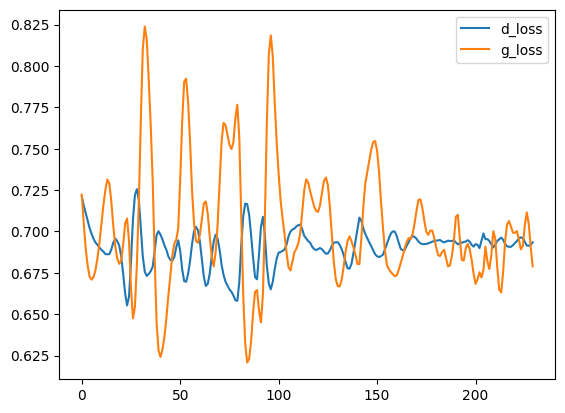

In [5]:


class GAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.seed_generator = keras.random.SeedGenerator(42)

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        # Sample random points in the latent space
        batch_size = ops.shape(real_images)[0]
        random_latent_vectors = keras.random.normal(
            shape=(batch_size, self.latent_dim), seed=self.seed_generator
        )

        # Decode them to fake images
        generated_images = self.generator(random_latent_vectors)

        # Combine them with real images
        combined_images = ops.concatenate([generated_images, real_images], axis=0)

        # Assemble labels discriminating real from fake images
        labels = ops.concatenate(
            [ops.ones((batch_size, 1)), ops.zeros((batch_size, 1))], axis=0
        )
        # Add random noise to the labels - important trick!
        #labels += 0.05 * tf.random.uniform(tf.shape(labels))

        # Train the discriminator
        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )

        # Sample random points in the latent space
        random_latent_vectors = keras.random.normal(
            shape=(batch_size, self.latent_dim), seed=self.seed_generator
        )

        # Assemble labels that say "all real images"
        misleading_labels = ops.zeros((batch_size, 1))

        # Train the generator (note that we should *not* update the weights
        # of the discriminator)!
        with tf.GradientTape() as tape:
            predictions = self.discriminator(self.generator(random_latent_vectors))
            g_loss = self.loss_fn(misleading_labels, predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        # Update metrics
        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        return {
            "d_loss": self.d_loss_metric.result(),
            "g_loss": self.g_loss_metric.result(),
        }
    
epochs = 230 

g_sch = keras.optimizers.schedules.ExponentialDecay(0.01,5000, 0.99)
d_sch = keras.optimizers.schedules.ExponentialDecay(0.1,5000, 0.99)

gan = GAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)
gan.compile(
    #d_optimizer=keras.optimizers.SGD(learning_rate=d_sch),
    #g_optimizer=keras.optimizers.SGD(learning_rate=g_sch),
    d_optimizer=keras.optimizers.Adam(0.0001),
    g_optimizer=keras.optimizers.Adam(0.0001),
    loss_fn=keras.losses.BinaryCrossentropy(),
)

h=gan.fit(points, epochs=epochs, batch_size=512, verbose=0)
pd.DataFrame(h.history).plot()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


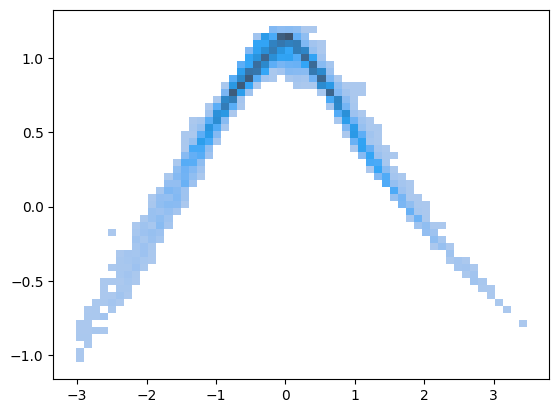

In [6]:
gen = generator.predict(np.random.normal(size=(10_000,latent_dim)))
sns.histplot(x=gen[:,0],y=gen[:,1], stat='density')
d = discriminator(gen)

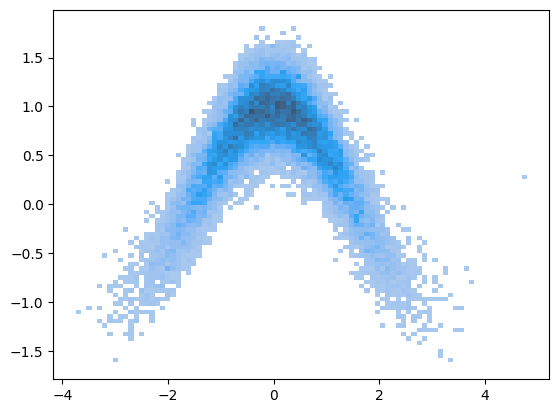

In [7]:
sns.histplot(x=points[:,0],y=points[:,1], stat='density');

# Dyfuzja

In [8]:
def diffuse(x, tidx, betas, return_eps=False):
    beta = betas[tidx]
    eps = keras.random.normal(shape=x.shape, dtype=x.dtype)
    x_noisy = ops.sqrt(1-beta)*x + ops.sqrt(beta)*eps
    if return_eps:
        return x_noisy, eps
    return x_noisy

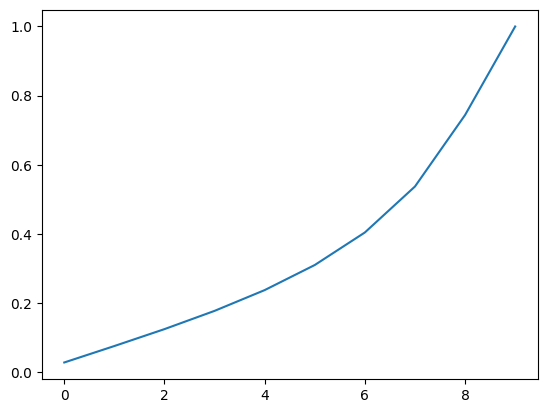

In [9]:
num_steps=10
cosine_s=0.008

ts = ops.arange(num_steps + 1)

alphas_bar = ops.cos((ts / num_steps + cosine_s) / (1 + cosine_s) * np.pi / 2)**2
alphas_bar = alphas_bar / ops.max(alphas_bar)
betas = 1 - alphas_bar[1:] / alphas_bar[:-1]
betas = ops.clip(betas, 0.0001, 0.9999)


#betas = ops.cast(betas, 'float32')
#alphas = ops.cast(1.0 - betas, 'float32')
alphas = 1.0 - betas
alphas_bar = ops.cumprod(alphas, axis=0)/alphas[0]

betas_tilde = (1 - alphas_bar[:-1]) / (1 - alphas_bar[1:]) * betas[1:]
betas_tilde = ops.pad(betas_tilde, pad_width=(1, 0), constant_values=0.0) # ensure betas_tilde[0] = 0.0
#betas_tilde = ops.cast(betas_tilde, 'float32')

plt.plot(betas)
 

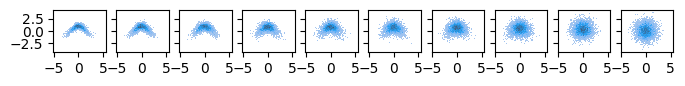

In [10]:

fig, axs = plt.subplots( ncols=num_steps, figsize=(8,240), sharey=True, sharex=True)

small_points = points

for i,ax in enumerate(axs):
    xn = diffuse(small_points, i, betas)
    sns.histplot(x=xn[:,0], y=xn[:,1], ax=ax)
    ax.set_aspect('equal')

## tf data

Potok danych do treningu

In [11]:
ds = tf.data.Dataset.from_tensor_slices(points.astype(np.float32))
ds = ds.map(lambda x: x)
ds = ds.batch(512)
#ds = ds.repeat(10)

## Harmonogramy Beta w Modelach Dyfuzyjnych

W procesie dyfuzji harmonogram $\beta_t$ kontroluje, ile szumu dodajemy na każdym kroku czasowym. W poniższym kodzie zdefiniowano dwa popularne harmonogramy:

### 1. Cosine Beta Schedule
- Opiera się na funkcji kosinusowej ([praca naukowa](https://arxiv.org/abs/2102.09672)).
- Łagodny początek (mniejsze \(\beta_t\)) i intensywniejszy koniec.
- Definiuje wartości \(\alpha_{cumprod}\) jako skumulowane kosinusy:
  $$\alpha_{cumprod} = \cos^2\left(\frac{\pi}{2} \cdot \frac{x / T + s}{1 + s}\right)$$
- $\beta_t$ wyznaczane z relacji:
  $$\beta_t = 1 - \frac{\alpha_{cumprod}[t]}{\alpha_{cumprod}[t-1]}$$

### 2. Sigmoid Beta Schedule
- Wykorzystuje funkcję sigmoidalną.
- Powolny wzrost na początku i końcu, szybszy w środku.
- Definicja:
  $$\beta_t = \text{sigmoid}(\text{linspace}(-6, 6)) \cdot (\beta_{end} - \beta_{start}) + \beta_{start}$$

Oba harmonogramy mają na celu poprawę jakości procesu dyfuzji przez optymalizację ilości dodawanego szumu.




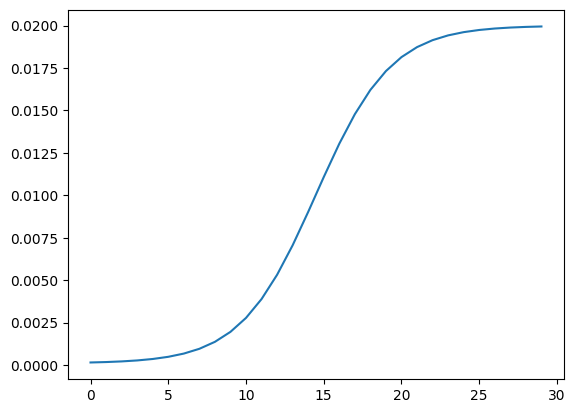

In [12]:
def cosine_beta_schedule(timesteps, s=0.008):
    """
    cosine schedule as proposed in https://arxiv.org/abs/2102.09672
    """
    steps = timesteps + 1
    x = ops.linspace(0, timesteps, steps)
    alphas_cumprod = ops.cos(((x / timesteps) + s) / (1 + s) * np.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return ops.clip(betas, 0.0001, 0.9999)

def sigmoid_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    betas = ops.linspace(-6, 6, timesteps)
    return ops.sigmoid(betas) * (beta_end - beta_start) + beta_start
plt.plot(sigmoid_beta_schedule(30))

### Implementacja modelu dyfuzyjnego

In [13]:
def extract(a, t, x_shape):
    batch_size = ops.shape(t)[0]
    out = ops.take(a, t, -1)
    return ops.reshape(out, (batch_size, *((1,) * (len(x_shape) - 1))))


class DiffusionModel(keras.Model):
    def __init__(self, num_steps: int, eps_model, *args, **kwargs):

        self.betas = cosine_beta_schedule(timesteps=num_steps)
        self.betas = sigmoid_beta_schedule(timesteps=num_steps)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = ops.cumprod(self.alphas, axis=0)
        self.alphas_cumprod_prev = ops.pad(
            self.alphas_cumprod[:-1], pad_width=(1, 0), constant_values=1.0
        )
        self.sqrt_recip_alphas = ops.sqrt(1.0 / self.alphas)

        # calculations for diffusion q(x_t | x_{t-1}) and others
        self.sqrt_alphas_cumprod = ops.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = ops.sqrt(1.0 - self.alphas_cumprod)

        # calculations for posterior q(x_{t-1} | x_t, x_0)
        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )

        self.eps_model = eps_model
        # self.dtype = dtype
        self.seed_generator = keras.random.SeedGenerator(42)
        super().__init__(*args, **kwargs)


    def randn_like(self, x):
        noise = keras.random.normal(
            ops.shape(x), dtype=x.dtype, seed=self.seed_generator
        )
        return noise

    def q_sample(self, x_start, t, noise=None):
        """Dyfuzja"""
        if noise is None:
            noise = self.randn_like(x_start)

        sqrt_alphas_cumprod_t = extract(self.sqrt_alphas_cumprod, t, x_start.shape)

        sqrt_one_minus_alphas_cumprod_t = extract(
            self.sqrt_one_minus_alphas_cumprod, t, x_start.shape
        )

        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise


    def index_to_float(self, t_ind):
        t = (t_ind + 1 )/ ops.convert_to_tensor(self.betas.shape[0])
        return t

    def p_sample(self, x, t):
        betas_t = extract(self.betas, t, x.shape)

        sqrt_one_minus_alphas_cumprod_t = extract(
            self.sqrt_one_minus_alphas_cumprod, t, x.shape
        )
        sqrt_recip_alphas_t = extract(self.sqrt_recip_alphas, t, x.shape)

        features = (x, self.index_to_float(t) )

        model_mean = sqrt_recip_alphas_t * (
            x - betas_t * self.eps_model(features) / sqrt_one_minus_alphas_cumprod_t
        )

        posterior_variance_t = extract(self.posterior_variance, t, x.shape)

        noise = ops.where(t>0, self.randn_like(x), ops.zeros_like(x))
        return model_mean + ops.sqrt(posterior_variance_t) * noise
        #return model_mean + 0.01 * noise

    def train_step(self, x):
        batch_size = ops.shape(x)[0]
        t_ind = keras.random.randint(
            shape=(batch_size,1), minval=0, maxval=self.betas.shape[0]
        )
        t = self.index_to_float(t_ind)
        eps = self.randn_like(x)
        x_noisy = self.q_sample(x,t_ind, eps)
        #x_noisy, eps = self.diffuse_to_step(x, t_ind, return_eps=True)
        with tf.GradientTape() as tape:
            noise_hat = self.eps_model((x_noisy, t))
            loss = ops.mean(self.loss(noise_hat, eps))
        grads = tape.gradient(loss, self.eps_model.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.eps_model.trainable_weights))
        for m in self.metrics:
            m.update_state(loss)
        return {"loss": loss}
        # +return self.eps_model.train_on_batch((x_noisy,t),x, return_dict=True)

## Zadanie zaimplementować siec neuronową dla modelu dyfuzyjnego

Siec przyjmuje 

- wektor 2d
- Czas - skalar
  
### Zwracamy wektor 2 d

In [14]:
# TODO
xin = keras.Input(shape=(2,), batch_size=512)
tin = keras.Input(shape=(1,), batch_size=512)

all_in = ops.concatenate([xin, tin], axis=1)

eps_hat = keras.Sequential(
    [
        keras.layers.Dense(128, activation="selu"),
        keras.layers.Dense(128, activation="selu"),
        keras.layers.Dense(2),
    ]
)(all_in)

eps_model = keras.Model(inputs=[xin, tin], outputs=eps_hat)

dm = DiffusionModel(40, eps_model)
dm.compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.MeanSquaredError())

h = dm.fit(ds, epochs=90)

Epoch 1/90
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8663
Epoch 2/90
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8003
Epoch 3/90
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7851
Epoch 4/90
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7650
Epoch 5/90
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7715
Epoch 6/90
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7648
Epoch 7/90
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7506
Epoch 8/90
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7645
Epoch 9/90
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7509
Epoch 10/90
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7465
Epoch 11/90
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7344
Epoch 12/90
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7415
Epoch 13/90
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7408
Epoch 14/90
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7520
Epoch 15/90
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7442
Epoch 16/90
40/40 ━

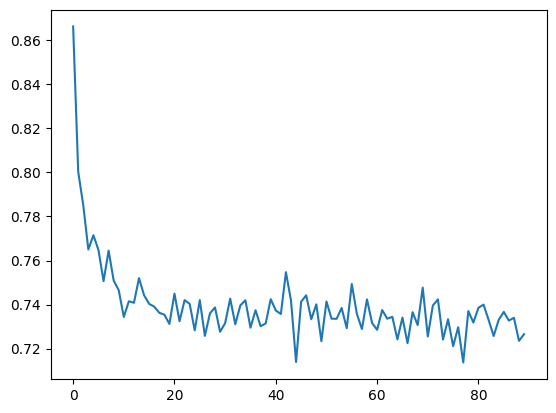

In [15]:
plt.plot(h.history['loss'])

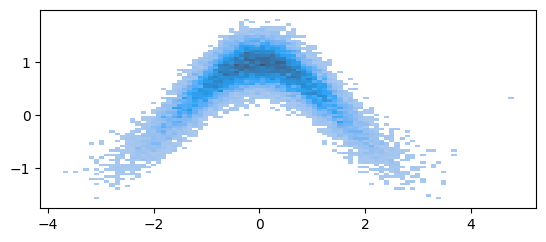

In [16]:
tt = ops.convert_to_tensor([[2]])
noisy_points = dm.q_sample(points.astype('float32'),tt, None)
sns.histplot(x=noisy_points[:,0],y=noisy_points[:,1], stat='density')
plt.gca().set_aspect('equal')

In [17]:
tt = ops.convert_to_tensor(points.shape[0]*[[2]])
dm.p_sample(noisy_points, tt)

<tf.Tensor: shape=(20000, 2), dtype=float32, numpy=
array([[-1.6464757 , -0.09270467],
       [-0.10608059,  0.6538105 ],
       [-1.8216037 , -0.3909573 ],
       ...,
       [-1.3268526 ,  0.2822815 ],
       [-0.30379695,  0.8469586 ],
       [ 0.3332607 ,  1.0128049 ]], shape=(20000, 2), dtype=float32)>

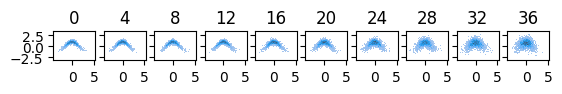

In [18]:
ns = len(dm.betas)
step=4
fig, axs = plt.subplots( ncols=ns//step, sharex=True, sharey=True)

for i in range(0,ns,step):
    diffused = dm.q_sample(points.astype(np.float32),ops.convert_to_tensor([i]))
    sns.histplot(x=diffused[:,0],y=diffused[:,1], stat='density', ax = axs[i//step])
    axs[i//step].set_title(f'{i}')
    axs[i//step].set_aspect('equal')


## Generacja nowych danych

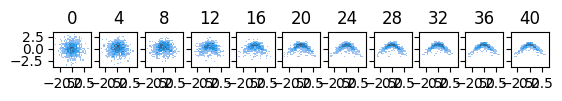

In [19]:
def sample(self:DiffusionModel, n_gen=20_000):
    x_gen = keras.random.normal((n_gen,2),dtype='float32')

    x_gens = [x_gen]

    for idx, tidx in enumerate(reversed(range(self.betas.shape[0]))):
        t = ops.convert_to_tensor(n_gen*[[tidx]])
        x_gen = dm.p_sample(x_gen, t)
        x_gens.append(x_gen)
    return x_gens

x_gens = sample(dm,1000)

step=4

fig, axs = plt.subplots( ncols=len(x_gens)//step+1, sharex=True, sharey=True)

# for xg,ax in zip(x_gens,axs):
for i in range(0, len(x_gens),step):
    xg = x_gens[i]
    sns.histplot(x=xg[:,0],y=xg[:,1], stat='density', ax=axs[i//step])
    axs[i//step].set_title(f'{i}')
    axs[i//step].set_aspect('equal')

<Axes: >

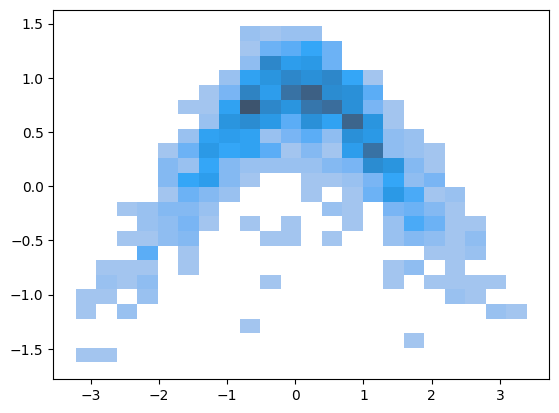

In [20]:
sns.histplot(x=xg[:,0],y=xg[:,1], stat='density')